In [1]:
"""import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset (replace with the correct file path)
file_path = r"D:\CRG\Diageo\Malt Spirit Process - Parameters and Outcome - V04.xlsx"  # Update this with the correct path
mashing_data = pd.read_excel(file_path, sheet_name='Mashing', header=1)"""

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\harsh\AppData\Local\Temp\ipykernel_28808\3865903942.py:1: SyntaxWarning: invalid escape sequence '\C'
  """import pandas as pd


'import pandas as pd\nimport statsmodels.api as sm\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.metrics import mean_squared_error, r2_score\n\n# Load the dataset (replace with the correct file path)\nfile_path = r"D:\\CRG\\Diageo\\Malt Spirit Process - Parameters and Outcome - V04.xlsx"  # Update this with the correct path\nmashing_data = pd.read_excel(file_path, sheet_name=\'Mashing\', header=1)'

In [2]:
"""# Define the training variables (Wort IQP columns) and target variable
wort_iqp_columns = [
    'Malt Hot Water Extract 6-Row (% w/w)',
    'Malt Predicted Spirit Yield 6-Row (LA/T',
    'Malt Grist Ratio - Coarse (%w/w)',
    'Malt Grist Ratio - Medium (%w/w)', 
    'Malt Grist Ratio - Fine (%w/w)',
    'Malt Moisture', 
    'Malt Friability 6-Row'
] 

# Target variable (update if necessary)
target_variable = 'First Wort Collection - Turbidity'  

# Extract the relevant data
X = mashing_data[wort_iqp_columns]
y = mashing_data[target_variable]"""

"# Define the training variables (Wort IQP columns) and target variable\nwort_iqp_columns = [\n    'Malt Hot Water Extract 6-Row (% w/w)',\n    'Malt Predicted Spirit Yield 6-Row (LA/T',\n    'Malt Grist Ratio - Coarse (%w/w)',\n    'Malt Grist Ratio - Medium (%w/w)', \n    'Malt Grist Ratio - Fine (%w/w)',\n    'Malt Moisture', \n    'Malt Friability 6-Row'\n] \n\n# Target variable (update if necessary)\ntarget_variable = 'First Wort Collection - Turbidity'  \n\n# Extract the relevant data\nX = mashing_data[wort_iqp_columns]\ny = mashing_data[target_variable]"

In [3]:
"""# Handle missing values by dropping rows with missing values
X = X.dropna()
y = y.dropna()

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Add a constant (intercept) to the training and testing sets
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)"""

'# Handle missing values by dropping rows with missing values\nX = X.dropna()\ny = y.dropna()\n\n# Split the data into training and testing sets (80% training, 20% testing)\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)\n\n# Add a constant (intercept) to the training and testing sets\nX_train = sm.add_constant(X_train)\nX_test = sm.add_constant(X_test)'

In [4]:
"""# Stepwise Regression function (Forward and Backward)
def stepwise_selection(X, y, 
                       initial_list=[], 
                       threshold_in=0.05, 
                       threshold_out=0.05, 
                       verbose=True):
    
    included = list(initial_list)
    while True:
        changed = False
        
        # Forward step: try adding a variable
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)
        
        for new_column in excluded:
            model = sm.OLS(y, X[included + [new_column]]).fit()
            new_pval[new_column] = model.pvalues[new_column]
        
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print(f'Adding {best_feature} with p-value {best_pval}')
        
        # Backward step: try removing a variable
        model = sm.OLS(y, X[included]).fit()
        pvalues = model.pvalues.iloc[1:]  # Exclude the constant term
        worst_pval = pvalues.max()
        if worst_pval > threshold_out:
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            changed = True
            if verbose:
                print(f'Removing {worst_feature} with p-value {worst_pval}')
        
        if not changed:
            break

    return included
"""

"# Stepwise Regression function (Forward and Backward)\ndef stepwise_selection(X, y, \n                       initial_list=[], \n                       threshold_in=0.05, \n                       threshold_out=0.05, \n                       verbose=True):\n    \n    included = list(initial_list)\n    while True:\n        changed = False\n        \n        # Forward step: try adding a variable\n        excluded = list(set(X.columns) - set(included))\n        new_pval = pd.Series(index=excluded)\n        \n        for new_column in excluded:\n            model = sm.OLS(y, X[included + [new_column]]).fit()\n            new_pval[new_column] = model.pvalues[new_column]\n        \n        best_pval = new_pval.min()\n        if best_pval < threshold_in:\n            best_feature = new_pval.idxmin()\n            included.append(best_feature)\n            changed = True\n            if verbose:\n                print(f'Adding {best_feature} with p-value {best_pval}')\n        \n        # Backwa

In [5]:
#X_train = X_train.apply(pd.to_numeric, errors='coerce')

In [6]:
#y_train = pd.to_numeric(y_train, errors='coerce')

In [7]:
#X_aligned = X_train.loc[y_train.index]

In [8]:
#y_train = y_train[X_aligned.index]

In [9]:
"""# Perform stepwise selection
resulting_features = stepwise_selection(X_aligned, y_train)

# Fit the final model using the selected features
final_model = sm.OLS(y_train, X_train[resulting_features]).fit()

# Display the summary of the final model
print(final_model.summary())

# Make predictions on the test set
y_pred = final_model.predict(X_test[resulting_features])

# Evaluate the model performance on the test set
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")"""

'# Perform stepwise selection\nresulting_features = stepwise_selection(X_aligned, y_train)\n\n# Fit the final model using the selected features\nfinal_model = sm.OLS(y_train, X_train[resulting_features]).fit()\n\n# Display the summary of the final model\nprint(final_model.summary())\n\n# Make predictions on the test set\ny_pred = final_model.predict(X_test[resulting_features])\n\n# Evaluate the model performance on the test set\nmse = mean_squared_error(y_test, y_pred)\nr2 = r2_score(y_test, y_pred)\n\nprint(f"\nModel Evaluation:")\nprint(f"Mean Squared Error: {mse}")\nprint(f"R-squared: {r2}")'

In [10]:
"""import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set(style='whitegrid')

# Scatter Plot of Actual vs. Predicted Values
plt.figure(figsize=(14, 6))

# Scatter Plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # Perfect prediction line
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.xlim(y_test.min(), y_test.max())
plt.ylim(y_test.min(), y_test.max())
plt.grid()

# Residuals Plot
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid()

# Show the plots
plt.tight_layout()
plt.show()"""

"import matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Set the style for the plots\nsns.set(style='whitegrid')\n\n# Scatter Plot of Actual vs. Predicted Values\nplt.figure(figsize=(14, 6))\n\n# Scatter Plot\nplt.subplot(1, 2, 1)\nplt.scatter(y_test, y_pred, alpha=0.6)\nplt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')  # Perfect prediction line\nplt.title('Actual vs. Predicted Values')\nplt.xlabel('Actual Values')\nplt.ylabel('Predicted Values')\nplt.xlim(y_test.min(), y_test.max())\nplt.ylim(y_test.min(), y_test.max())\nplt.grid()\n\n# Residuals Plot\nplt.subplot(1, 2, 2)\nresiduals = y_test - y_pred\nplt.scatter(y_pred, residuals, alpha=0.6)\nplt.axhline(0, color='red', linestyle='--')\nplt.title('Residuals vs. Predicted Values')\nplt.xlabel('Predicted Values')\nplt.ylabel('Residuals')\nplt.grid()\n\n# Show the plots\nplt.tight_layout()\nplt.show()"

In [11]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset (replace with the correct file path)
file_path = r"D:\CRG\Diageo\Malt Spirit Process - Parameters and Outcome - V04.xlsx"  # Update this with the correct path
mashing_data = pd.read_excel(file_path, sheet_name='Mashing', header=1)

In [12]:
mashing_data

,Mash B#,Malt Hot Water Extract 6-Row (% w/w),1000 Kernel Weight (g),Malt Predicted Spirit Yield 6-Row (LA/T,Malt Fermentability,Malt Grist Ratio - Coarse (%w/w),Malt Grist Ratio - Medium (%w/w),Malt Grist Ratio - Fine (%w/w),Malt Moisture,Malt Friability 6-Row,...,Raking Arms Speed,Mashing - Striking Temp.,Draff Loss,Resting Time,Wort Collection - Flow Rate,First Wort Collection - Turbidity,First Wort Collection - Gravity,Weak Wort Gravity,Weak Wort Clarity,Weak Wort Temperature.1
0,830.0,74.023745,NaN,341.478997,NaN,17.0,76.0,7.0,4.67,69.22,...,0.33,65.4,0.40,25.0,140.0,255.0,1.075,1.006,1.0,75.7
1,831.0,74.036378,NaN,341.537275,NaN,17.0,75.0,8.0,4.58,70.90,...,0.33,65.8,0.41,25.0,140.0,268.0,1.072,1.005,1.0,75.4
2,832.0,74.05902,NaN,341.641724,NaN,17.0,75.0,8.0,4.60,68.88,...,0.33,65.2,0.38,25.0,140.0,265.0,1.072,1.005,1.0,76.6
3,833.0,74.012442,NaN,341.426855,NaN,18.0,75.0,7.0,4.66,69.99,...,0.33,66.1,0.39,25.0,140.0,270.0,1.070,1.005,1.0,76.6
4,834.0,74.515776,NaN,343.748786,NaN,17.0,76.0,7.0,4.76,70.10,...,0.33,65.5,0.40,25.0,140.0,240.0,1.075,1.005,1.0,76.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,477.0,74.297864,NaN,342.743536,NaN,18.0,74.0,8.0,4.28,70.48,...,0.33,65.0,0.40,25.0,140.0,233.0,1.073,1.005,1.0,76.4
76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
77,NaN,IQP,Ingredient or intermediate Quality Parameter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
78,NaN,PRP,Process Parameter,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
mashing_data.columns

Index(['Mash B#', 'Malt Hot Water Extract 6-Row (% w/w)',
       '1000 Kernel Weight (g)', 'Malt Predicted Spirit Yield 6-Row (LA/T',
       'Malt Fermentability', 'Malt Grist Ratio - Coarse (%w/w)',
       'Malt Grist Ratio - Medium (%w/w)', 'Malt Grist Ratio - Fine (%w/w)',
       'Malt Moisture', 'Malt Friability 6-Row',
       'Shelf life at the time of receipt (%)',
       'Shelf life at use/consumption (no. of days)', 'Water Sensory',
       'Water pH', 'Water TDS', 'Water Hardness', 'Water Chloride',
       'Water Alkalinity', 'Water Free Chlorine', 'Grist Quantity',
       'Sparging Temperature 1', 'Sparging Temperature 2',
       'Mash Vessel Turnaround Time', 'Weak Wort Temperature',
       'Raking Arms Speed', 'Mashing - Striking Temp.', 'Draff Loss',
       'Resting Time', 'Wort Collection - Flow Rate',
       'First Wort Collection - Turbidity', 'First Wort Collection - Gravity',
       'Weak Wort Gravity', 'Weak Wort Clarity', 'Weak Wort Temperature.1'],
      dtype='obje

In [14]:
# Define the training variables (Wort IQP columns)
wort_iqp_columns = [
    'Malt Hot Water Extract 6-Row (% w/w)',
    'Malt Predicted Spirit Yield 6-Row (LA/T',
    'Malt Grist Ratio - Coarse (%w/w)',
    'Malt Grist Ratio - Medium (%w/w)', 
    'Malt Grist Ratio - Fine (%w/w)',
    'Malt Moisture', 
    'Malt Friability 6-Row'
] 

# Target variables (update if necessary)
target_variables = ['First Wort Collection - Turbidity', 'First Wort Collection - Gravity']

In [15]:
# Extract the relevant data
X = mashing_data[wort_iqp_columns]
X = X.dropna()  # Handle missing values in predictors

In [16]:
# Function for Stepwise Selection (same as before)
def stepwise_selection(X, y, 
                       initial_list=[], 
                       threshold_in=0.05, 
                       threshold_out=0.05, 
                       verbose=True):
    
    included = list(initial_list)
    while True:
        changed = False
        
        # Forward step: try adding a variable
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)
        
        for new_column in excluded:
            model = sm.OLS(y, X[included + [new_column]]).fit()
            new_pval[new_column] = model.pvalues[new_column]
        
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print(f'Adding {best_feature} with p-value {best_pval}')
        
        # Backward step: try removing a variable
        model = sm.OLS(y, X[included]).fit()
        pvalues = model.pvalues.iloc[1:]  # Exclude the constant term
        worst_pval = pvalues.max()
        if worst_pval > threshold_out:
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            changed = True
            if verbose:
                print(f'Removing {worst_feature} with p-value {worst_pval}')
        
        if not changed:
            break

    return included

# Iterate through each target variable and perform stepwise regression
for target_variable in target_variables:
    y = mashing_data[target_variable].dropna()  # Get the target variable and drop missing values
    X = X.apply(pd.to_numeric, errors='coerce')
    y = pd.to_numeric(y, errors='coerce')
    X_aligned = X.loc[y.index]  # Align predictors with the target variable's index
    y = y[X_aligned.index]

    # Perform stepwise selection
    resulting_features = stepwise_selection(X_aligned, y)

    # Fit the final model using the selected features
    final_model = sm.OLS(y, X_aligned[resulting_features]).fit()

    # Display the summary of the final model
    print(f"\nResults for {target_variable}:")
    print(final_model.summary())

    # Make predictions on the full dataset (or a test set if desired)
    y_pred = final_model.predict(X_aligned[resulting_features])

    # Evaluate the model performance
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print(f"Model Evaluation for {target_variable}:")
    print(f"Mean Squared Error: {mse}")
    print(f"R-squared: {r2}")


Adding Malt Hot Water Extract 6-Row (% w/w) with p-value 2.7296466187603076e-81
Adding Malt Predicted Spirit Yield 6-Row (LA/T with p-value 2.7296466187603076e-81

Results for First Wort Collection - Turbidity:
                                        OLS Regression Results                                        
Dep. Variable:     First Wort Collection - Turbidity   R-squared (uncentered):                   0.992
Model:                                           OLS   Adj. R-squared (uncentered):              0.992
Method:                                Least Squares   F-statistic:                              9829.
Date:                               Thu, 03 Oct 2024   Prob (F-statistic):                    2.73e-81
Time:                                       16:25:45   Log-Likelihood:                         -346.30
No. Observations:                                 76   AIC:                                      694.6
Df Residuals:                                     75   BIC:         

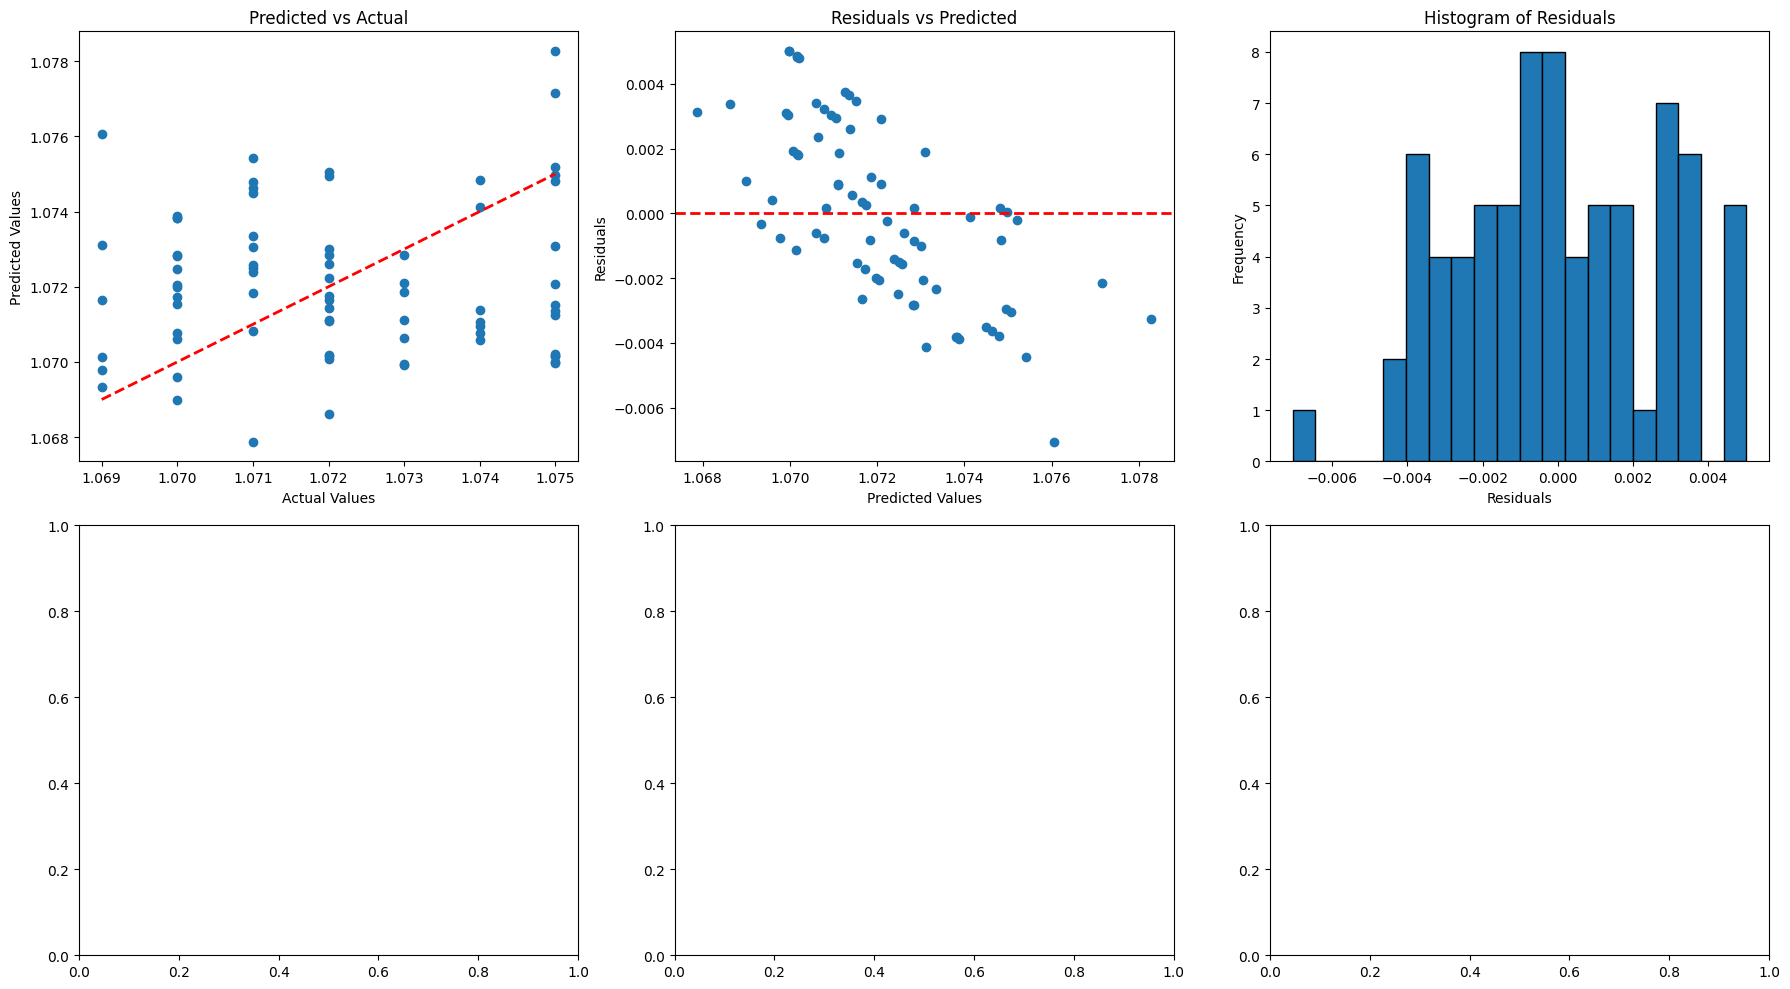

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming y and y_pred are defined as your actual and predicted values
# and residuals are calculated as follows
residuals = y - y_pred

# Set up for plotting
fig, axs = plt.subplots(2, 3, figsize=(18, 10))  # Create a 2x3 subplot layout

# Plotting Predicted vs Actual
axs[0, 0].scatter(y, y_pred)
axs[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axs[0, 0].set_title('Predicted vs Actual')
axs[0, 0].set_xlabel('Actual Values')
axs[0, 0].set_ylabel('Predicted Values')

# Plotting Residuals
axs[0, 1].scatter(y_pred, residuals)
axs[0, 1].axhline(0, color='red', linestyle='--', lw=2)
axs[0, 1].set_title('Residuals vs Predicted')
axs[0, 1].set_xlabel('Predicted Values')
axs[0, 1].set_ylabel('Residuals')

# Histogram of Residuals
axs[0, 2].hist(residuals, bins=20, edgecolor='black')
axs[0, 2].set_title('Histogram of Residuals')
axs[0, 2].set_xlabel('Residuals')
axs[0, 2].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()
